# Gate-fidelity-corrected data processing and figures

This notebook assembles the **gate-fidelity-corrected singlet curves** into publication-quality SI panels. It loads precomputed `alpha, P, FI` CSV products (suffix `*_corrected.csv`) and exports the corresponding figure PDFs.

## Inputs
- `data_analysis/singlet_U{ x,y,z }_alpha_P_FI_1218_corrected.csv`

## Outputs
- `si_figures/SI_fig_v3_c_gate.pdf` (plus intermediate combined-panel exports)

```mermaid
flowchart LR
  in["Gate-corrected `alpha, P, FI` CSVs\n(`data_analysis/*_corrected.csv`)"] --> grid["Interpolate to a common α grid\n+ compute mean FI"]
  grid --> out["Export SI PDFs"]
```


## Setup and data loading

This cell locates `data_analysis/`, loads the gate-fidelity-corrected singlet CSV files, and exposes arrays for plotting.


In [1]:
import os
from pathlib import Path

# Ensure relative paths work regardless of where the notebook is launched from.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data").exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print("Working directory:", Path.cwd())

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Locate data_analysis relative to common notebook working directories.
candidates = [
    Path('data_analysis'),
    Path('../data_analysis'),
    Path('../Data_analysis'),
    Path.cwd() / 'data_analysis',
    Path.cwd().parent / 'data_analysis',
]
data_analysis_dir = None
for p in candidates:
    if p.exists():
        data_analysis_dir = p
        break

if data_analysis_dir is None:
    raise FileNotFoundError('Could not locate data_analysis directory.')

date_suffix_gate = '1218_corrected'

def load_alpha_P_FI(base_name, suffix=date_suffix_gate):
    file_path = data_analysis_dir / f'{base_name}_alpha_P_FI_{suffix}.csv'
    if not file_path.exists():
        matches = sorted(data_analysis_dir.glob(f'{base_name}_alpha_P_FI_*corrected.csv'))
        if not matches:
            raise FileNotFoundError(f'No corrected CSV found for {base_name}.')
        file_path = matches[-1]

    arr = np.loadtxt(file_path, delimiter=',', skiprows=1)
    alpha = arr[:, 0]
    P = arr[:, 1]
    FI = arr[:, 2]
    return file_path, alpha, P, FI

ux_path, alpha_Ux_gate, P_Ux_gate, FI_Ux_gate = load_alpha_P_FI('singlet_Ux')
uy_path, alpha_Uy_gate, P_Uy_gate, FI_Uy_gate = load_alpha_P_FI('singlet_Uy')
uz_path, alpha_Uz_gate, P_Uz_gate, FI_Uz_gate = load_alpha_P_FI('singlet_Uz')

print('Loaded:')
print(' ', ux_path)
print(' ', uy_path)
print(' ', uz_path)
print('Shapes:', P_Ux_gate.shape, P_Uy_gate.shape, P_Uz_gate.shape)



Working directory: /Users/chellymac/projects/positronium-sensing
Loaded:
  data_analysis/singlet_Ux_alpha_P_FI_1218_corrected.csv
  data_analysis/singlet_Uy_alpha_P_FI_1218_corrected.csv
  data_analysis/singlet_Uz_alpha_P_FI_1218_corrected.csv
Shapes: (100,) (100,) (100,)


## Global plot style

Style settings align with the singlet FI analysis notebooks (03–04) so that SI panels are visually consistent.


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style: axes + ticks (SI panel styling) ---
lw = 1
mpl.rcParams['axes.linewidth'] = lw
mpl.rcParams['lines.linewidth'] = lw
mpl.rcParams['xtick.major.width'] = lw
mpl.rcParams['ytick.major.width'] = lw
mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'
import shutil
_HAS_TEX = all(shutil.which(cmd) for cmd in ('latex', 'dvipng', 'gs'))
mpl.rcParams['text.usetex'] = _HAS_TEX
mpl.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'
    r'\DeclareUnicodeCharacter{03B1}{\ensuremath{\alpha}}'
    if _HAS_TEX else ''
)

def _ket(state: str) -> str:
    if mpl.rcParams['text.usetex']:
        return rf'\left\lvert{{{state}}}\right\rangle'
    return rf'\left|{{{state}}}\right\rangle'

ket_psi = _ket(r'\Psi^-')
ket_xp = _ket('x+')
ket_zp = _ket('z+')
ket_1 = _ket('1')
ket_01 = _ket('01')

# Figure size (8.6 cm × 5 cm) -> inches
fig_size = np.asarray([8.6, 5]) / 2.54

# Axis styles (consistent x/y/z color + marker mapping)
style_x = dict(color='#6D00C9', marker='s', linestyle='-', markersize=5.0, label=r'$\hat{\boldsymbol{x}}$')
style_y = dict(color='#F9AE2A', marker='^', linestyle='-', markersize=5.0, label=r'$\hat{\boldsymbol{y}}$')
style_z = dict(color='#777777', marker='o', linestyle='-', markersize=5.0, label=r'$\hat{\boldsymbol{z}}$')

# Common x ticks in units of pi
xticks = [0, np.pi, 2*np.pi]
xticklabels = [r'$0$', r'$\pi$', r'$2\pi$']





## Common alpha grid

A single overlap alpha grid is used for all three axes so combined and average plots are internally consistent.


In [3]:
import numpy as np

def _prep_alpha_y(alpha, y):
    alpha = np.asarray(alpha, float)
    y = np.asarray(y, float)
    m = np.isfinite(alpha) & np.isfinite(y)
    alpha, y = alpha[m], y[m]
    order = np.argsort(alpha)
    return alpha[order], y[order]

Ux_a_P, Ux_P = _prep_alpha_y(alpha_Ux_gate, P_Ux_gate)
Uy_a_P, Uy_P = _prep_alpha_y(alpha_Uy_gate, P_Uy_gate)
Uz_a_P, Uz_P = _prep_alpha_y(alpha_Uz_gate, P_Uz_gate)

Ux_a_FI, Ux_FI = _prep_alpha_y(alpha_Ux_gate, FI_Ux_gate)
Uy_a_FI, Uy_FI = _prep_alpha_y(alpha_Uy_gate, FI_Uy_gate)
Uz_a_FI, Uz_FI = _prep_alpha_y(alpha_Uz_gate, FI_Uz_gate)

alpha_min_overlap = max(np.nanmin(Ux_a_P), np.nanmin(Uy_a_P), np.nanmin(Uz_a_P))
alpha_max_overlap = min(np.nanmax(Ux_a_P), np.nanmax(Uy_a_P), np.nanmax(Uz_a_P))
if not (alpha_max_overlap > alpha_min_overlap):
    raise ValueError('No overlap among alpha grids for Ux/Uy/Uz.')

N_common = min(len(Ux_a_P), len(Uy_a_P), len(Uz_a_P))
alpha_common = np.linspace(alpha_min_overlap, alpha_max_overlap, N_common)

alpha_xlim_min = alpha_min_overlap
alpha_xlim_max = alpha_max_overlap

P_Ux_common = np.interp(alpha_common, Ux_a_P, Ux_P)
P_Uy_common = np.interp(alpha_common, Uy_a_P, Uy_P)
P_Uz_common = np.interp(alpha_common, Uz_a_P, Uz_P)

FI_Ux_common = np.interp(alpha_common, Ux_a_FI, Ux_FI)
FI_Uy_common = np.interp(alpha_common, Uy_a_FI, Uy_FI)
FI_Uz_common = np.interp(alpha_common, Uz_a_FI, Uz_FI)

FI_mean_common = (FI_Ux_common + FI_Uy_common + FI_Uz_common) / 3.0

# Downsample for plotting only
DOWNSAMPLE_FRAC = 0.7
n = len(alpha_common)
m = max(2, int(round(DOWNSAMPLE_FRAC * n)))
idx_ds = np.linspace(0, n - 1, m).astype(int)

alpha_common_ds = alpha_common[idx_ds]

P_Ux_ds = P_Ux_common[idx_ds]
P_Uy_ds = P_Uy_common[idx_ds]
P_Uz_ds = P_Uz_common[idx_ds]

FI_Ux_ds = FI_Ux_common[idx_ds]
FI_Uy_ds = FI_Uy_common[idx_ds]
FI_Uz_ds = FI_Uz_common[idx_ds]

FI_mean_ds = FI_mean_common[idx_ds]



## Gate-fidelity-corrected combined figures

These panels overlay Ux/Uy/Uz curves in one frame for probability and FI.


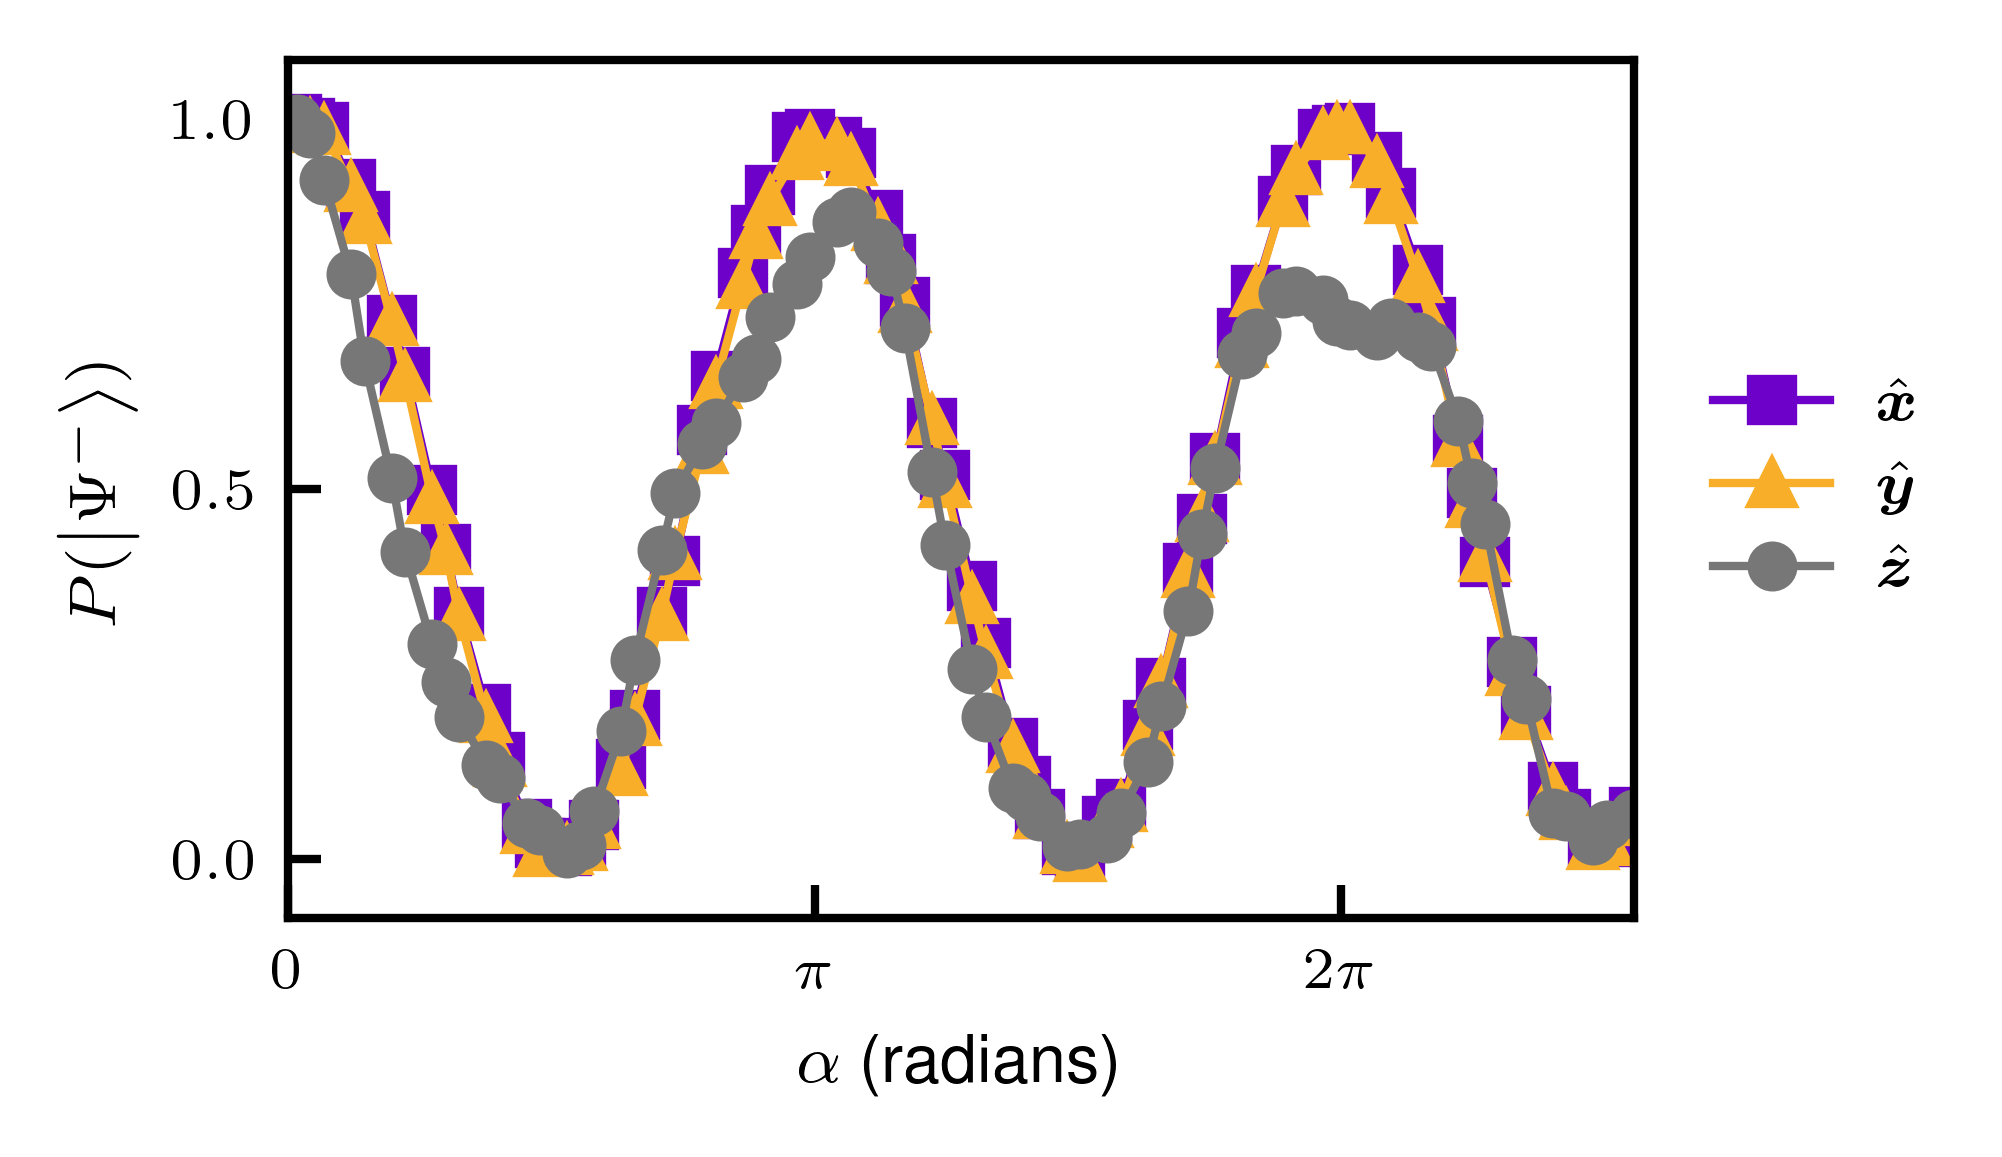

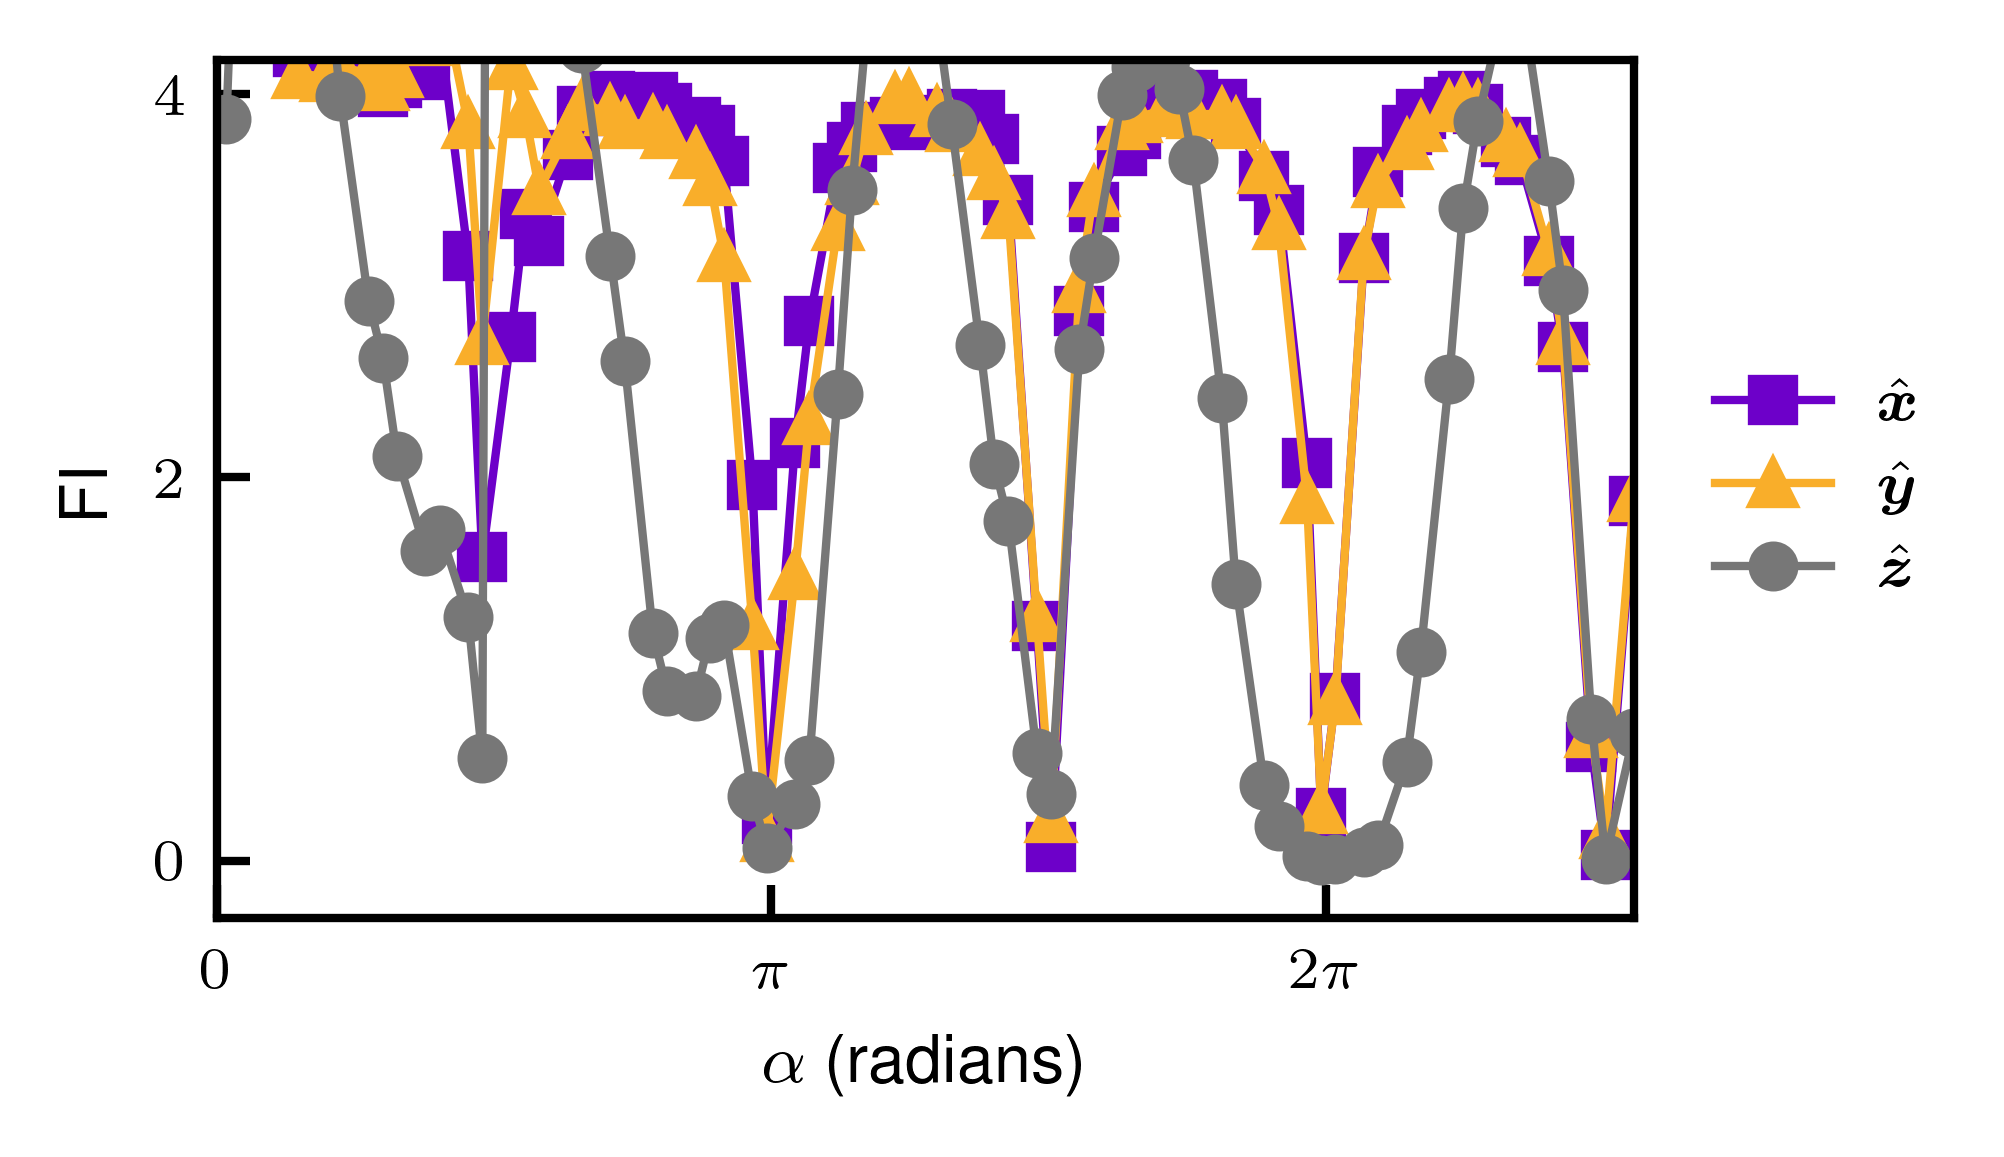

In [4]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# P(|Psi->) combined
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, P_Ux_ds, **style_x)
ax.plot(alpha_common_ds, P_Uy_ds, **style_y)
ax.plot(alpha_common_ds, P_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.08, 1.08)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel(r'$\alpha$ (radians)')
ax.set_ylabel(fr'$P({ket_psi})$')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='x', which='major', bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction='in')
ax.tick_params(axis='y', which='major', left=True, right=False, labelleft=True,
               length=4, width=lw, direction='in')

fig.tight_layout()
outpath_p = os.path.join('si_figures', 'SI_fig_v2_gate_P_combined.pdf')
os.makedirs(os.path.dirname(outpath_p), exist_ok=True)
fig.savefig(outpath_p, bbox_inches='tight')
plt.show()

# FI combined
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, FI_Ux_ds, **style_x)
ax.plot(alpha_common_ds, FI_Uy_ds, **style_y)
ax.plot(alpha_common_ds, FI_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r'$\alpha$ (radians)')
ax.set_ylabel('FI')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='x', which='major', bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction='in')
ax.tick_params(axis='y', which='major', left=True, right=False, labelleft=True,
               length=4, width=lw, direction='in')

fig.tight_layout()
outpath_fi = os.path.join('si_figures', 'SI_fig_v2_gate_FI_combined.pdf')
fig.savefig(outpath_fi, bbox_inches='tight')
plt.show()







## Gate-fidelity-corrected average FI

The mean FI curve is shown together with a horizontal average line.
For this gate-corrected case, singular values above 4 are excluded when computing the horizontal average level.


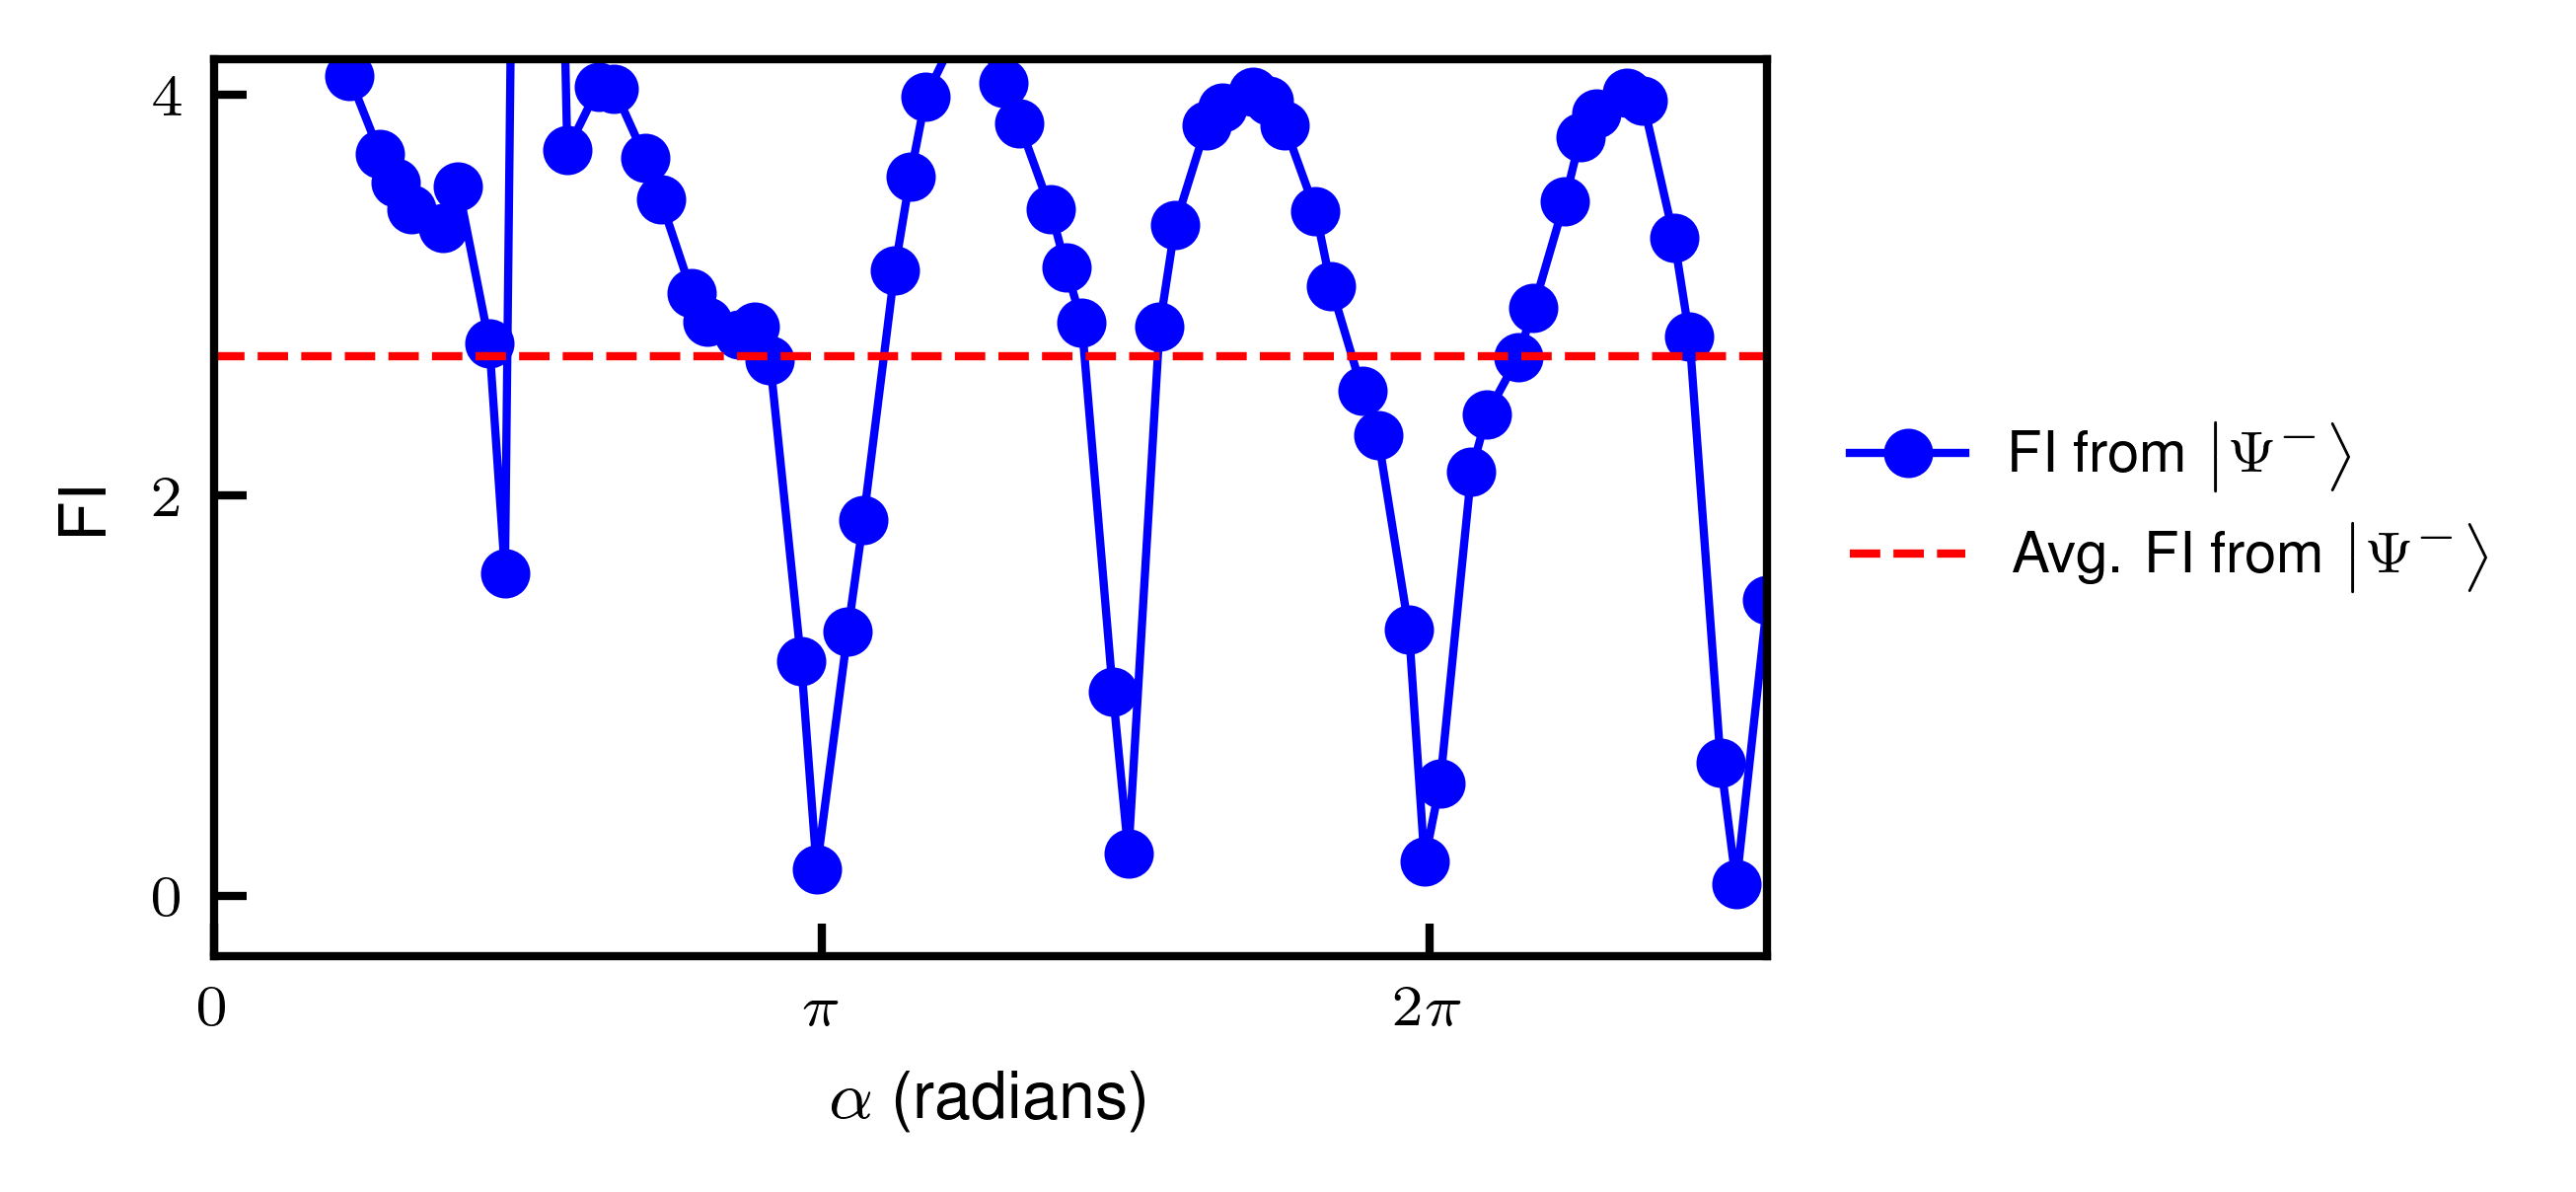

Average FI level (<=4 only): 2.6942946656961304


In [5]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

style_mean = dict(color='blue', marker='o', linestyle='-', markersize=5.0, label=fr'FI from ${ket_psi}$')
style_hline = dict(color='red', linestyle='--', linewidth=1.0, label=fr'Avg. FI from ${ket_psi}$')

singlet_Uxyz_mean_FI_ds_gate = FI_mean_ds
valid_mask = np.isfinite(singlet_Uxyz_mean_FI_ds_gate) & (singlet_Uxyz_mean_FI_ds_gate <= 4)
singlet_FI_ds_gate_mean = np.mean(singlet_Uxyz_mean_FI_ds_gate[valid_mask])

fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, singlet_Uxyz_mean_FI_ds_gate, **style_mean)
ax.axhline(singlet_FI_ds_gate_mean, **style_hline)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r'$\alpha$ (radians)')
ax.set_ylabel('FI')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='x', which='major', bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction='in')
ax.tick_params(axis='y', which='major', left=True, right=False, labelleft=True,
               length=4, width=lw, direction='in')

outpath = os.path.join('si_figures', 'SI_fig_v3_c_gate.pdf')
os.makedirs(os.path.dirname(outpath), exist_ok=True)
fig.savefig(outpath, bbox_inches='tight')
plt.show()

print('Average FI level (<=4 only):', singlet_FI_ds_gate_mean)





